In [93]:
# colab setup
colab = False
file_name = 'test'

In [99]:
%load_ext autoreload
%autoreload 2
if colab:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd drive/MyDrive/ecg_arrhythmia/
    !pip install wfdb wget numpy pandas scipy scikit-learn tensorflow matplotlib seaborn PyWavelets
    !pip install --upgrade wfdb
from hyperparams import *
from tasks import *
from plot import *
from model import *
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [100]:
# download_data()

In [101]:
mitdb, pwave = get_records(mitdb_dir, pwave_dir)

In [ ]:
# 전체 데이터를 저장할 리스트 초기화
all_segments = []
all_features = []
all_labels = []
all_records = []
df_records = pd.DataFrame(columns=['record', 'num_segments'])

# record별 전처리
for record in mitdb:
    # load ECG signal & annotations
    signals, fields = load_ECG_signal(record)
    signals = np.squeeze(signals)
    annotations = load_ECG_annotations(record=record, dir=mitdb_dir, extension='atr')
    
    # bandpass & R-peak detection with wavelet or pantompkins
    bpsig = bandpass_filter(signals)
    # rpeaks = get_rpeaks(bpsig) # wavelet
    rpeaks = get_rpeaks_pantompkins(bpsig) # pantompkins

    # segmentation
    segments = segment_heartbeats(bpsig, rpeaks) 

    # fill Nan, IQR clipping, remove constant features
    segments = fill_nan(segments)
    segments = IQR_clipping(segments) 
    segments = remove_const_features(segments)

    # P-peak detection
    ppeaks = get_ppeaks(record, bpsig, rpeaks)
    
    # remove 1st and last R-peak & match P,R peaks
    rpeaks = rpeaks[1:-1]
    ppeaks = match_pr(rpeaks, ppeaks)

    # T-peak detection
    tpeaks = get_tpeaks(bpsig, rpeaks)

    # feature extraction for 2nd input
    feat_scale, feat_not_scale = extract_features(bpsig, rpeaks, ppeaks, tpeaks)

    # normalization
    feat_scale = feature_scaling(feat_scale) #TODO : feat_notscale concat
    print(f"feat_scale shape: {feat_scale.shape}, feat_not_scale shape: {feat_not_scale.shape}")
    extracted_features = np.concatenate([feat_scale, feat_not_scale], axis=1)
    print(f"extracted_features shape: {extracted_features.shape}")
    segments = feature_scaling(segments)

    # label extraction & grouping
    labels = extract_labels(rpeaks, annotations, record)
    labels = list(map(group_labels, labels))

    # split을 위한 record 인덱스 array 생성
    record_idx = np.array([record]*len(labels)) #TODO: len(labels)를 더 안전한 방법이 있는지 고민
    df_records.loc[len(df_records)] = [record, len(labels)]

    # 데이터를 리스트에 추가
    all_segments.append(segments)
    all_features.append(extracted_features)
    all_labels.append(labels)
    all_records.append(record_idx)

    
    
x1 = np.concatenate(all_segments, axis=0)
x2 = np.concatenate(all_features, axis=0)
y = np.concatenate(all_labels, axis=0)
records = np.concatenate(all_records, axis=0)


print("Segments(x1) Shape:", x1.shape)
print("Extracted Features(x2) Shape:", x2.shape)
print("Labels(y) Shape:", y.shape)


rpeaks shape: (2208,), ppeaks shape: (2208,), tpeaks shape: (144,)
feat_scale shape: (144, 12), feat_not_scale shape: (144, 3)
extracted_features shape: (144, 15)
rpeak: 649764, ann_idx: 2141 ann_sample length:2141, ann_symbol length:2141
rpeaks shape: (2296,), ppeaks shape: (2296,), tpeaks shape: (142,)
feat_scale shape: (142, 12), feat_not_scale shape: (142, 3)
extracted_features shape: (142, 15)


KeyboardInterrupt: 

In [56]:
df_records.num_segments.describe()

count      48.000000
mean     2344.854167
std       423.596104
min      1530.000000
25%      2065.000000
50%      2270.000000
75%      2623.250000
max      3362.000000
Name: num_segments, dtype: float64

In [57]:
# 시간 기준 data split
# 초기화
train_indices = []
val_indices = []
test_indices = []

# 각 record별로 데이터 분리
start_idx = 0
for idx, row in df_records.iterrows():
    record_name = row['record']
    num_segments = row['num_segments']
    
    # 인덱스 범위 계산
    record_indices = np.arange(start_idx, start_idx + num_segments)
    start_idx += num_segments
    
    # 상위 70%, 중간 15%, 하위 15%로 분리
    num_train = int(num_segments * 0.7)
    num_val = int(num_segments * 0.15)
    num_test = num_segments - (num_train + num_val)
    
    train_indices.extend(record_indices[:num_train])
    val_indices.extend(record_indices[num_train:num_train + num_val])
    test_indices.extend(record_indices[num_train + num_val:])

# 데이터 분리
x1_train, x1_val, x1_test = x1[train_indices], x1[val_indices], x1[test_indices]
x2_train, x2_val, x2_test = x2[train_indices], x2[val_indices], x2[test_indices]
y_train, y_val, y_test = y[train_indices], y[val_indices], y[test_indices]
records_train, records_val, records_test = records[train_indices], records[val_indices], records[test_indices]

# 결과 확인
print("Train Data:")
print("Segments(x1) Shape:", x1_train.shape)
print("Extracted Features(x2) Shape:", x2_train.shape)
print("Labels(y) Shape:", y_train.shape)
print("Validation Data:")
print("Segments(x1) Shape:", x1_val.shape)
print("Extracted Features(x2) Shape:", x2_val.shape)
print("Labels(y) Shape:", y_val.shape)
print("Test Data:")
print("Segments(x1) Shape:", x1_test.shape)
print("Extracted Features(x2) Shape:", x2_test.shape)
print("Labels(y) Shape:", y_test.shape)


Train Data:
Segments(x1) Shape: (78767, 300)
Extracted Features(x2) Shape: (78767, 16)
Labels(y) Shape: (78767,)
Validation Data:
Segments(x1) Shape: (16860, 300)
Extracted Features(x2) Shape: (16860, 16)
Labels(y) Shape: (16860,)
Test Data:
Segments(x1) Shape: (16926, 300)
Extracted Features(x2) Shape: (16926, 16)
Labels(y) Shape: (16926,)


In [ ]:
# # record 기준 data split
# # combine x1, x2 for split
# x1x2 = np.hstack((x1, x2))

# # data split stratified
# sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
# for fold, (train_val_idx, test_idx) in enumerate(sgkf.split(x1x2, y, groups=records)):
#     break    
# x1x2_train_val = x1x2[train_val_idx]
# y_train_val = y[train_val_idx]
# records_train_val = records[train_val_idx]

# # Train/Validation 데이터를 다시 StratifiedGroupKFold로 나누기
# sgkf_val = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
# for train_idx, val_idx in sgkf_val.split(x1x2_train_val,y_train_val, groups=records_train_val):
#     break  # 첫 번째 split을 사용하여 Train/Validation 분할

# x1_train = x1x2_train_val[train_idx][:, :x1.shape[1]]
# x2_train = x1x2_train_val[train_idx][:, x1.shape[1]:]
# x1_val = x1x2_train_val[val_idx][:, :x1.shape[1]]
# x2_val = x1x2_train_val[val_idx][:, x1.shape[1]:]
# x1_test = x1x2[test_idx][:, :x1.shape[1]]
# x2_test = x1x2[test_idx][:, x1.shape[1]:]

# y_train = y_train_val[train_idx]
# y_val = y_train_val[val_idx]
# y_test = y[test_idx]



In [59]:
# one-hot encoding
y_train_oh, class_names = one_hot_encoder(y_train)
y_val_oh, _ = one_hot_encoder(y_val)
y_test_oh, _ = one_hot_encoder(y_test)

In [60]:
# model initialization
x1_shape = (x1_train.shape[1], 1)
x2_shape = (x2_train.shape[1],)
n_classes = y_train_oh.shape[1]
model = CNNModel(x1_shape, x2_shape, n_classes)   

In [61]:
# model training
model.fit([x1_train, x2_train], y_train_oh, [x1_val, x2_val], y_val_oh, y_train)

Epoch 1/50
2462/2462 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - accuracy: 0.6930 - loss: 2.4225 - val_accuracy: 0.8555 - val_loss: 0.5380
Epoch 2/50
2462/2462 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - accuracy: 0.8522 - loss: 0.5671 - val_accuracy: 0.8569 - val_loss: 0.5022
Epoch 3/50
2462/2462 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.8620 - loss: 0.5043 - val_accuracy: 0.8866 - val_loss: 0.4288
Epoch 4/50
 126/2462 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - accuracy: 0.8776 - loss: 0.4431

KeyboardInterrupt: 

In [13]:
# model evaluation
test_loss, test_accuracy = model.evaluate([x1_test,x2_test], y_test_oh)
print(f"Test accuracy: {test_accuracy:.4f}")

528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8239 - loss: 0.6517
Test accuracy: 0.8233


528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
              precision    recall  f1-score   support

      Atrial       0.98      0.10      0.18       415
      Normal       0.86      0.91      0.88     11067
       Other       0.89      0.73      0.81      4165
 Ventricular       0.43      0.61      0.50      1236

    accuracy                           0.82     16883
   macro avg       0.79      0.59      0.59     16883
weighted avg       0.84      0.82      0.82     16883

         Class  Precision    Recall  F1-Score  Specificity
0       Atrial   0.976190  0.098795  0.179431     0.999939
1       Normal   0.862356  0.907473  0.884339     0.724381
2        Other   0.890311  0.734694  0.805051     0.970357
3  Ventricular   0.429465  0.610841  0.504342     0.935898


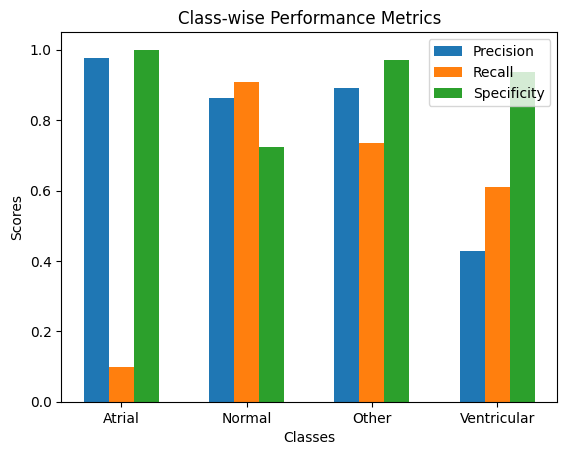

In [14]:
# prediction
y_pred = model.predict([x1_test, x2_test])
y_test = np.argmax(y_test_oh, axis=1)  

# get precision, recall, f1-score, specificity
precision, recall, f1, specificity = calc_metrics(y_test, y_pred, class_names)
global_metrics = calc_global_metrics(y_test, y_pred)

# report
print(classification_report(y_test, y_pred, target_names=class_names))
# get metric df
metric_df = get_metric_df(precision, recall, f1, specificity, class_names)
print(metric_df)


# histogram
plot_metric_hist(precision, recall, specificity, class_names)


In [ ]:
# data export for colab
if colab:
    df_to_csv_colab(metric_df, file_name+'.csv')
    dict_to_json_colab(global_metrics, file_name+'.json')

NameError: name 'file_name' is not defined